#### Com a análise explorativa feita no arquivo [analise_exploratoria.py](analise_exploratoria.ipynb), surgem algumas perguntas, junto ao proposto no arquivo [descricao_desafio.md](../descricao_desafio.md) feito por josé Gonçalves Jr.

1. Qual o comparativo da taxa de execução no período dos anos nas funções de Saúde, Educação e Cultura?
2. Quais capitais pagam uma proporção maior do que empenha nessas 3 funções? em resumo, quais capitais conseguem além de pagar tudo empenhado, pagar as despessas processadas dos anos anteriores? E quais deixam mais despesas liquidadas ou não, para o próximo ano?
3. Maceió investe mais em Cultura do que a média geral das outras capitais brasileiras? (per-capta)
4. Qual a evolução da taxa de execução dessas áreas? Se estiver crescendo a área da cultura, qual subárea está tendo maior priorização?

Essas perguntas são norteadores e dão contexto ao que se espera que essa análise irá percorrer.


In [1]:
""" Importação das dependências para a análise """

from src.query_descritiva import (
    tabela_filtrada,
    tabela_com_taxa_execucao,
    obter_dados_pagamento_vs_divida,
    obter_dados_cultura_per_capita,
)
from src.config.grafico import configurar_graficos
from src.config.ConexaoBanco import db

configurar_graficos()

┌─────────────────────────────────────────────┬─────────┬───────────────┬─────────────┬────────────────────────────────────────────────┬───────────┬─────────────────┬─────────────────┬───────────────┬──────────────────────────────────────┬──────────────────────────────────┐
│                 instituicao                 │   uf    │ ano_exercicio │ nome_funcao │                 nome_subfuncao                 │ populacao │ valor_empenhado │ valor_liquidado │  valor_pago   │ valor_restos_a_pagar_nao_processados │ valor_restos_a_pagar_processados │
│                   varchar                   │ varchar │     int64     │   varchar   │                    varchar                     │   int64   │     double      │     double      │    double     │                double                │              double              │
├─────────────────────────────────────────────┼─────────┼───────────────┼─────────────┼────────────────────────────────────────────────┼───────────┼─────────────────┼─────────

#### Tabela base para as análises

In [4]:
tabela_filtrada(db.con).df().describe(include="all")

,instituicao,uf,ano_exercicio,nome_funcao,nome_subfuncao,populacao,valor_empenhado,valor_liquidado,valor_pago,valor_restos_a_pagar_nao_processados,valor_restos_a_pagar_processados
count,2023,2023,2023.000000,2023,1633,2.023000e+03,2.022000e+03,2.017000e+03,2.016000e+03,1.595000e+03,1.622000e+03
unique,26,26,NaN,3,17,NaN,NaN,NaN,NaN,NaN,NaN
top,Prefeitura Municipal de São Paulo - SP,SP,NaN,Saúde,Administração Geral,NaN,NaN,NaN,NaN,NaN,NaN
freq,99,99,NaN,875,295,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2022.010875,NaN,NaN,1.950859e+06,6.039807e+08,5.642435e+08,5.503612e+08,5.131924e+07,1.761845e+07
std,NaN,NaN,1.415220,NaN,NaN,2.666173e+06,1.892568e+09,1.741578e+09,1.712665e+09,2.377022e+08,6.423491e+07
min,NaN,NaN,2020.000000,NaN,NaN,2.991270e+05,2.210100e+02,2.210100e+02,2.210100e+02,-2.471369e+07,-2.014236e+07
25%,NaN,NaN,2021.000000,NaN,NaN,6.053090e+05,1.277061e+07,1.126719e+07,1.089606e+07,8.766004e+05,2.052075e+05
50%,NaN,NaN,2022.000000,NaN,NaN,1.031597e+06,7.494385e+07,7.184843e+07,6.825971e+07,4.785806e+06,1.601472e+06
75%,NaN,NaN,2023.000000,NaN,NaN,2.054731e+06,4.756798e+08,4.382910e+08,4.270184e+08,2.354593e+07,8.997252e+06


### 1. Qual o comparativo da taxa de execução no período dos anos nas funções de Saúde, Educação e Cultura?

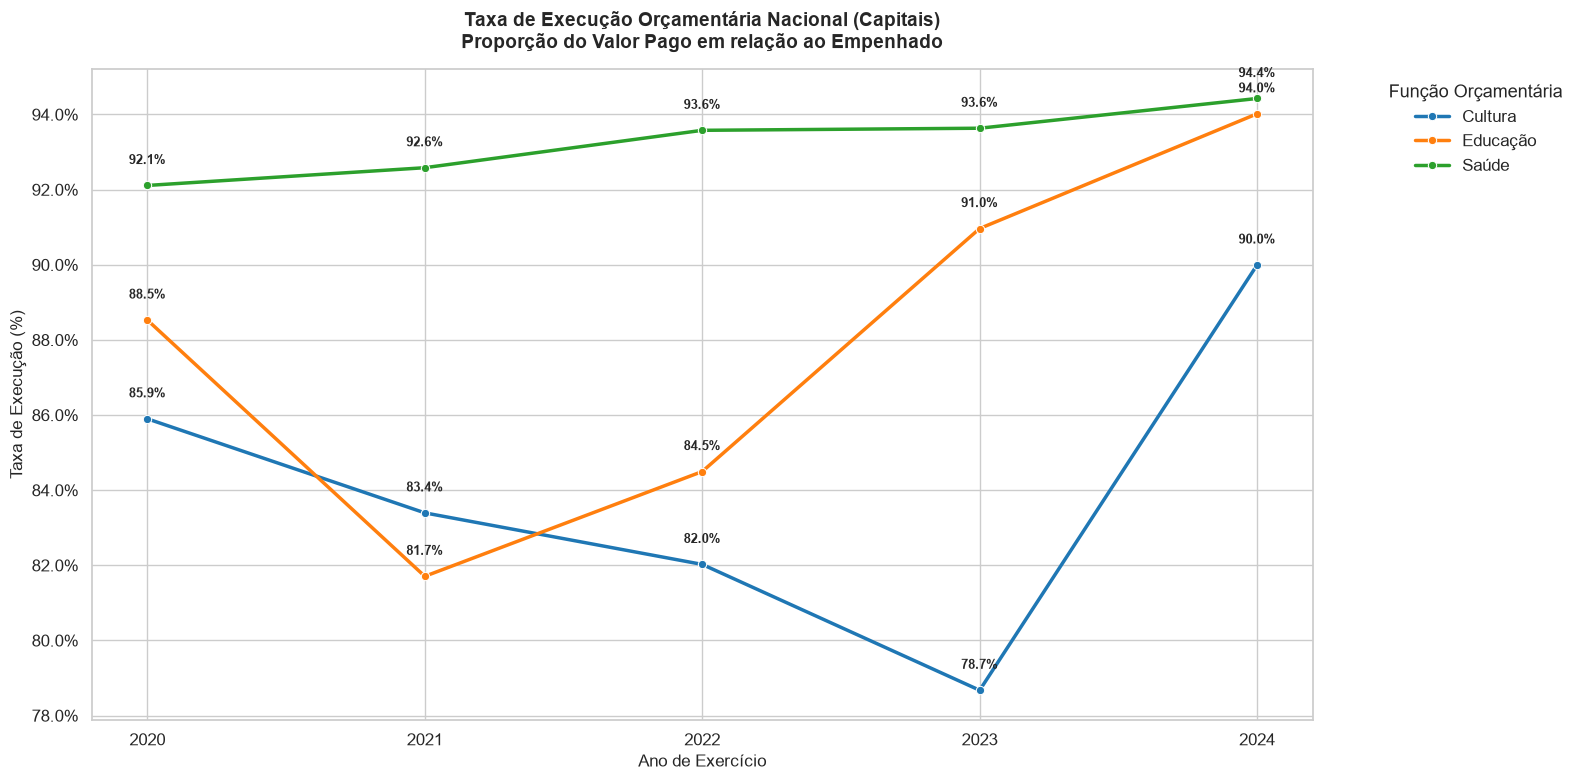

In [6]:
from src.visualizacao.linha_comparativo_tava_execucao import plotar_linha_taxa_execucao

df = tabela_com_taxa_execucao(db.con).df()
plotar_linha_taxa_execucao(df)

##### O gráfico revela o comportamento da taxa de execução orçamentária para as funções [Saúde, Educação e Cultura] analisadas entre 2020 e 2024:

`Saúde`: Apresenta um crescimento contínuo ao longo dos anos, com exceção do período entre 2022 e 2023, no qual a taxa de execução se estabilizou exatamente em 93.6%, houve um acréscimo apenas de 0.5% do ano de 2020 para 2021, apesar da pandemia do covid-19.

`Educação`: Registra uma queda abrupta de 2020 para 2021 (redução de 88.5% para 81.7%), dinâmica que coincide com o período da pandemia de COVID-19, seguida por uma recuperação constante nos anos posteriores.

`Cultura`: Mostra uma tendência de declínio até 2023, atingindo o ponto mais baixo da série com 78.7%. No entanto, a função apresenta uma forte reversão em 2024, registrando um aumento de mais de 11 pontos percentuais em apenas um ano e alcançando 90.0% de execução.

### 2. Quais capitais pagam uma proporção maior do que empenha nessas 3 funções?

#### SAÚDE

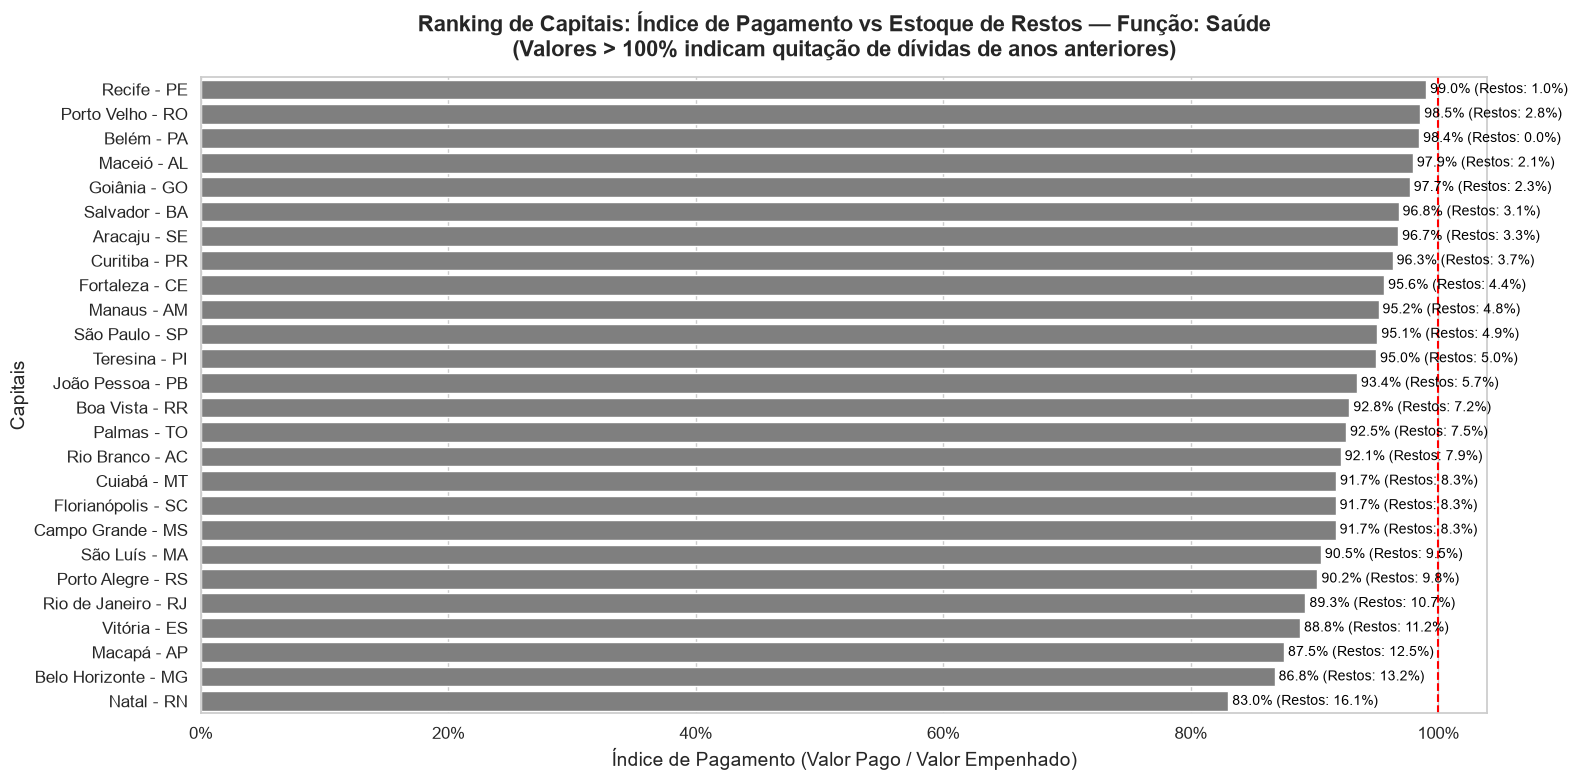

In [3]:
from src.visualizacao.bar_ranking_pagamento_divida import plotar_ranking_pagamento_vs_divida

df = obter_dados_pagamento_vs_divida(db.con).df()
plotar_ranking_pagamento_vs_divida(df, "Saúde")

O gráfico revela o alinhamento entre a eficiência de pagamento do ano corrente e o volume de dívidas herdadas do ano anterior:
*Os restos: xx,x% representam as dispesas herdadas não pagas e que passaram para o próximo ano*

`Desempenho das Capitais`: No topo do ranking, Recife (99.0%), Porto Velho (98.5%) e Belém (98.4%) lideram o índice de pagamento do que foi empenhado. Na ponta oposta, Natal (83.0%), Belo Horizonte (86.8%) e Macapá (87.5%) registram a menor eficiência de quitação.

`Cruzamento de Dados`: Há uma correlação inversa exata entre os indicadores. As capitais que menos pagam o orçamento corrente são as que mais acumulam Restos a Pagar (dívidas transferidas para o ano seguinte). Enquanto Recife deixa apenas 1.0% de resíduo, Natal posterga 16.1% e Belo Horizonte 13.2%.

`Saúde Fiscal vs Rolagem de Dívida`: Nenhuma capital superou a marca de 100%, indicando que não houve pagamento expressivo de passivos históricos na Saúde. As cidades no topo demonstram saúde fiscal ao honrar quase todo o empenho do período. Já as capitais na base utilizam a inscrição de Restos a Pagar como rolagem crônica de dívida entre exercícios, comprometendo o orçamento de Saúde do ano subsequente.

#### EDUCAÇÃO

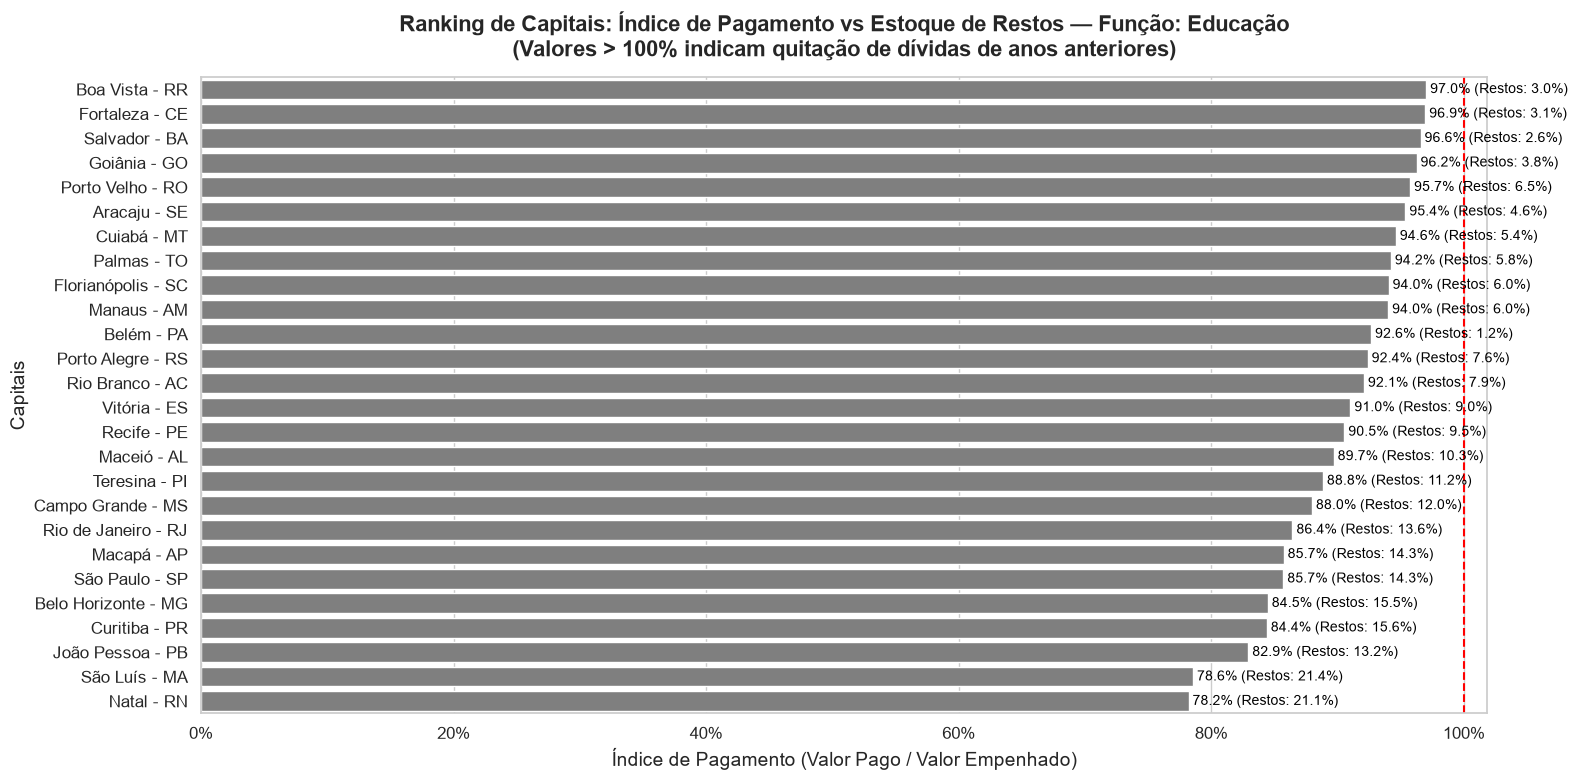

In [4]:
df = obter_dados_pagamento_vs_divida(db.con).df()
plotar_ranking_pagamento_vs_divida(df, "Educação")

O gráfico revela o alinhamento entre a eficiência de pagamento do ano corrente e o volume de dívidas herdadas do ano anterior:
*Os restos: xx,x% representam as despesas herdadas não pagas e que passaram para o próximo ano*

`Desempenho das Capitais`: No topo do ranking, Boa Vista (97.0%), Fortaleza (96.9%) e Salvador (96.6%) lideram o índice de pagamento do que foi empenhado. Na ponta oposta, Natal (78.2%), São Luís (78.6%) e João Pessoa (82.9%) registram a menor eficiência de quitação.

`Cruzamento de Dados`: Há uma correlação inversa exata entre os indicadores. As capitais que menos pagam o orçamento corrente são as que mais acumulam Restos a Pagar (dívidas transferidas para o ano seguinte). Enquanto Salvador deixa apenas 2.6% de resíduo e Boa Vista 3.0%, São Luís posterga 21.4% e Natal 21.1%.

`Educação Fiscal vs Rolagem de Dívida`: Nenhuma capital superou a marca de 100%, indicando que não houve pagamento expressivo de passivos históricos na Educação. As cidades no topo demonstram saúde fiscal ao honrar quase todo o empenho do período. Já as capitais na base utilizam a inscrição de Restos a Pagar como rolagem crônica de dívida entre exercícios, comprometendo consideravelmente o orçamento de Educação do ano subsequente com mais de um quinto das despesas adiadas.

#### CULTURA

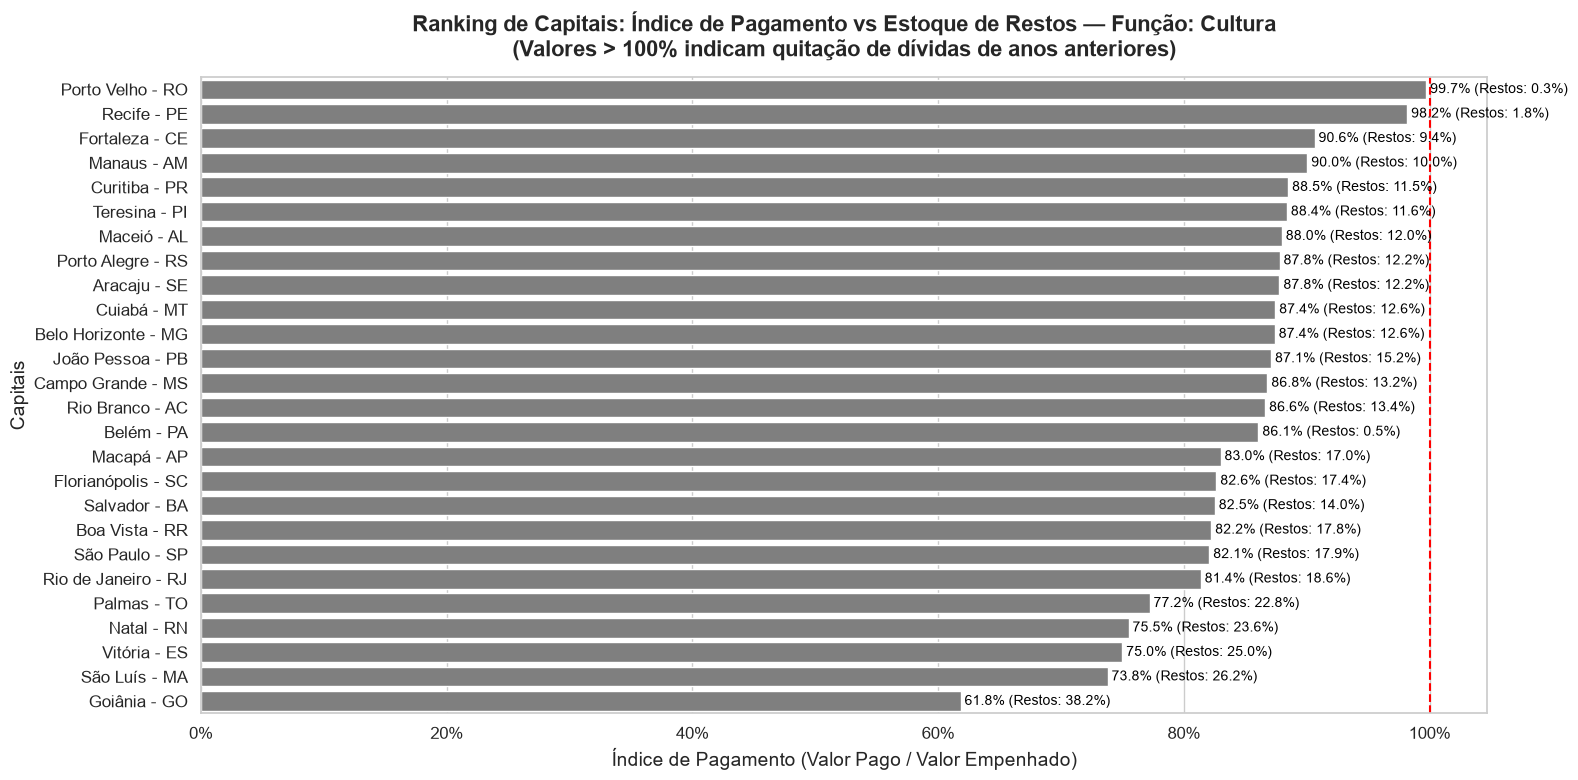

In [5]:
from src.visualizacao.bar_ranking_pagamento_divida import plotar_ranking_pagamento_vs_divida

df = obter_dados_pagamento_vs_divida(db.con).df()
plotar_ranking_pagamento_vs_divida(df, "Cultura")

O gráfico revela o alinhamento entre a eficiência de pagamento do ano corrente e o volume de dívidas herdadas do ano anterior:
*Os restos: xx,x% representam as despesas herdadas não pagas e que passaram para o próximo ano*

`Desempenho das Capitais`: No topo do ranking, Porto Velho (99.7%), Recife (98.2%) e Fortaleza (90.6%) lideram o índice de pagamento do que foi empenhado. Na ponta oposta, Goiânia (61.8%), São Luís (73.8%) e Vitória (75.0%) registram a menor eficiência de quitação.

`Cruzamento de Dados`: Há uma correlação inversa exata entre os indicadores. As capitais que menos pagam o orçamento corrente são as que mais acumulam Restos a Pagar (dívidas transferidas para o ano seguinte). Enquanto Porto Velho deixa apenas 0.3% de resíduo e Recife 1.8%, Goiânia posterga 38.2% e São Luís 26.2%.

`Cultura Fiscal vs Rolagem de Dívida`: Nenhuma capital superou a marca de 100%, indicando que não houve pagamento expressivo de passivos históricos na Cultura. As cidades no topo demonstram saúde fiscal ao honrar quase todo o empenho do período. Já as capitais na base utilizam a inscrição de Restos a Pagar como rolagem crônica de dívida entre exercícios, comprometendo severamente o orçamento de Cultura do ano subsequente, chegando ao extremo de adiar mais de um terço de todas as suas despesas.

A comparação entre Saúde, Educação e Cultura mostra que a eficiência de pagamento varia por setor: a Saúde é a mais preservada, enquanto a Cultura sofre com o maior adiamento de despesas. Capitais como Recife e Porto Velho mantêm excelente saúde fiscal em todas as áreas, enquanto Natal e São Luís acumulam dívidas crônicas de forma generalizada. Como nenhuma cidade superou os 100% de pagamento, não há quitação de passivos antigos, gerando uma rolagem crônica de restos a pagar que sufoca o orçamento dos anos seguintes.

### 3. Maceió investe mais em Cultura do que a média geral das outras capitais brasileiras?

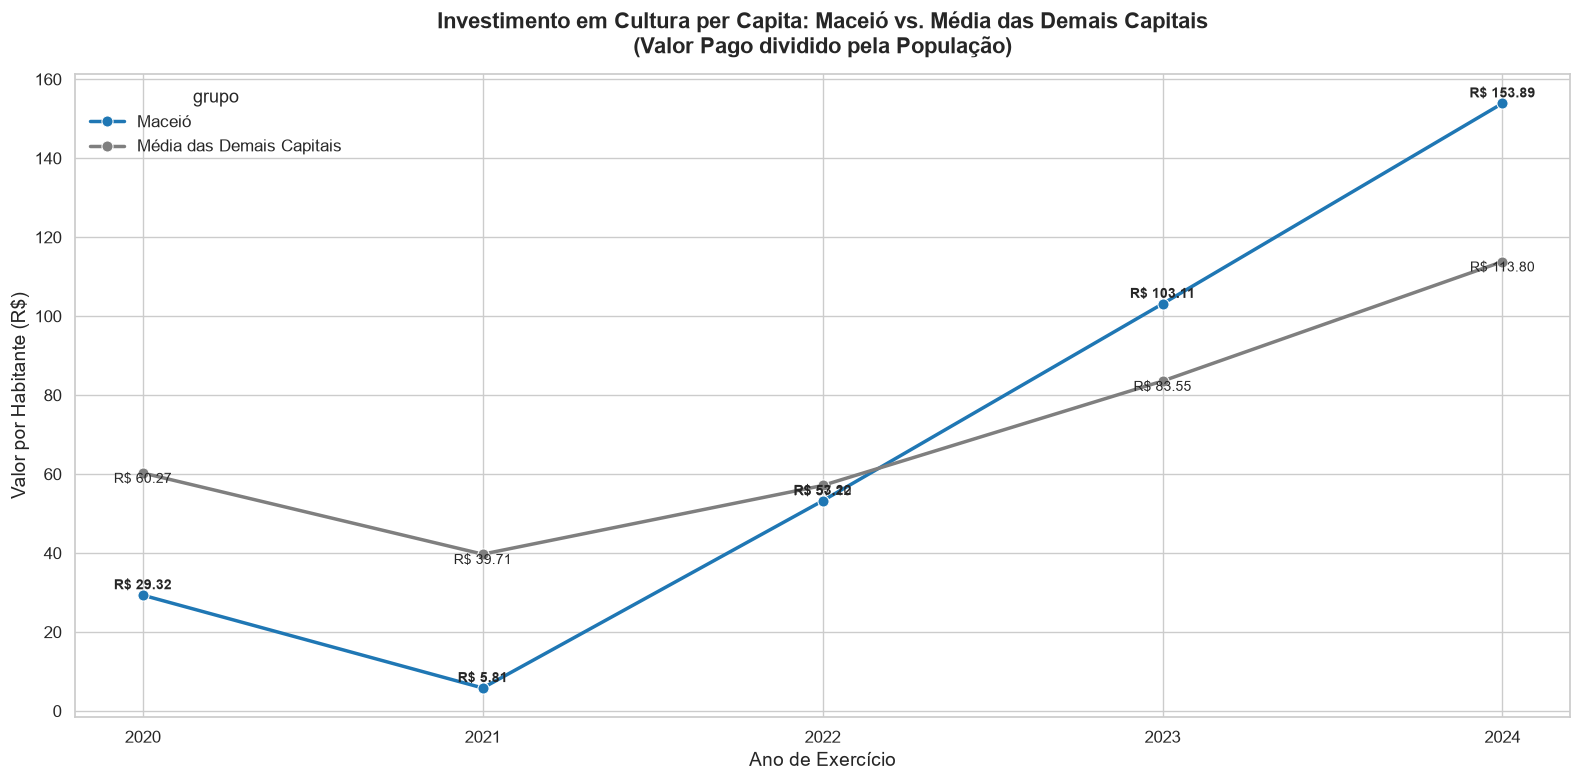

In [2]:
from src.visualizacao.linha_comparativo_cultura_per_capita import plotar_comparativo_cultura_per_capita

df = obter_dados_cultura_per_capita(db.con).df()
plotar_comparativo_cultura_per_capita(df)

O gráfico revela o comportamento do investimento em Cultura per capita de Maceió em comparação com a média das outras 25 capitais entre 2020 e 2024:

Houve um decaimento tanto de 2020 para 2021 na média geral quanto no de Maceió, em decorrência da pandemia da COVID-19. Mesmo assim, Maceió investia mais que a média das capitais até 2022. Nos anos seguintes, a capital se destacou por seu contínuo crescimento no orçamento cultural, terminando o período bem acima da média geral (R$ 51,96 em Maceió contra R$ 22,17 na média das demais capitais em 2024).